# 2026-013 Viral Titers / Restimulation Clone 13

Analysis of restimulation data.

## Initialize Environment

In [1]:
# Load Packages
library(fcexpr)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ggpubr)
library(ggsci)
library(stringr)
library(jsonlite)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘jsonlite’ was built under R version 4.4.3”


In [2]:
# Set Working Directory
setwd("/home/dalbao/FlowAnalysis/2026-013-ViralTiters")

# Load flow processing functions
source("/home/dalbao/FlowAnalysis/flowProcessing.R")

# Import sample codebook
codebook <- read.csv("D8Panel1Codebook.csv")

# Population schemas file
p.schemas <- "D8P1PopulationSchemas.json"

# Design schemas file
d.schemas <- "D8P1DesignSchemas.json"

# Load Workspace (or cached version if it exists)
workspace <- load_workspace_cached(
                wsp_file = "14-May-2026.wsp",
                rds_file = "260518-D8.rds",
                overwrite = FALSE # Set to TRUE to reprocess WSP and overwrite cached workspace
        )

# Extract Counts
counts <- workspace[["counts"]]


Attaching package: ‘rlang’


The following objects are masked from ‘package:jsonlite’:

    flatten, unbox



Attaching package: ‘rstatix’


The following object is masked from ‘package:stats’:

    filter



Attaching package: ‘purrr’


The following objects are masked from ‘package:rlang’:

    %@%, flatten, flatten_chr, flatten_dbl, flatten_int, flatten_lgl,
    flatten_raw, invoke, splice


The following object is masked from ‘package:jsonlite’:

    flatten




# Process Gating Data
Cleanup data to report only gates below CD8.

In [3]:
# Filter only samples in "Samples" FlowJoGroup
surface <- counts %>% filter((FlowJoGroup %in% c("NoStim", "Restim")))

# codebook contains a mapping of FileName metadata
# Join surface with codebook to get metadata
surface <- surface %>%
    left_join(  codebook,
                by = c("FileName" = "FileName"))

# Multiply FractionOfParent by 100 and rename to Percent
surface <- surface %>%
    mutate(FractionOfParent = FractionOfParent * 100) %>%
    rename(Percent = FractionOfParent)

head(surface)


,FileName,PopulationFullPath,Parent,Population,Count,ParentCount,Percent,xDim,yDim,eventsInside,FilePath,FlowJoGroup,ws,Group,Stim,TotalCount
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
1,Nostim_dID-1_E01.fcs,root,NA,root,754769,NA,NA,NA,NA,NA,/D:/UF%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/2026-013%20Viral%20Titer/Day%208/Nostim_dID-1_E01.fcs,NoStim,14-May-2026.wsp,dID,NoStim,25214917
2,Nostim_dID-1_E01.fcs,Lymphocytes,root,Lymphocytes,503407,754769,66.69683,FSC-A,SSC-A,1,/D:/UF%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/2026-013%20Viral%20Titer/Day%208/Nostim_dID-1_E01.fcs,NoStim,14-May-2026.wsp,dID,NoStim,25214917
3,Nostim_dID-1_E01.fcs,Lymphocytes/Single Cells,Lymphocytes,Lymphocytes/Single Cells,451723,503407,89.73316,FSC-W,FSC-H,1,/D:/UF%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/2026-013%20Viral%20Titer/Day%208/Nostim_dID-1_E01.fcs,NoStim,14-May-2026.wsp,dID,NoStim,25214917
4,Nostim_dID-1_E01.fcs,Lymphocytes/Single Cells/Single Cells,Lymphocytes/Single Cells,Single Cells/Single Cells,431403,451723,95.50167,SSC-W,SSC-H,1,/D:/UF%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/2026-013%20Viral%20Titer/Day%208/Nostim_dID-1_E01.fcs,NoStim,14-May-2026.wsp,dID,NoStim,25214917
5,Nostim_dID-1_E01.fcs,Lymphocytes/Single Cells/Single Cells/Live,Lymphocytes/Single Cells/Single Cells,Live,346942,431403,80.42179,Comp-PE-CF594-A,SSC-A,1,/D:/UF%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/2026-013%20Viral%20Titer/Day%208/Nostim_dID-1_E01.fcs,NoStim,14-May-2026.wsp,dID,NoStim,25214917
6,Nostim_dID-1_E01.fcs,Lymphocytes/Single Cells/Single Cells/Live/CD8,Lymphocytes/Single Cells/Single Cells/Live,CD8,62070,346942,17.89060,Comp-Alexa Fluor 700-A,Comp-BUV 396-A,1,/D:/UF%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/2026-013%20Viral%20Titer/Day%208/Nostim_dID-1_E01.fcs,NoStim,14-May-2026.wsp,dID,NoStim,25214917


Process df:

In [4]:
# Keep only observations in surface wherin PopulationFullPath contains
# "Lymphocytes/Single Cells/Single Cells/"
surface <- surface %>%
    filter(grepl("Lymphocytes/Single Cells/Single Cells/Live", PopulationFullPath))

# Remove "Lymphocytes/Single Cells/Single Cells/Live/" from PopulationFullPath
surface <- surface %>%
    mutate(PopulationFullPath = gsub("Lymphocytes/Single Cells/Single Cells/Live/", "", PopulationFullPath))

# Keep only PopulationFullPath that contains "Transduced" or is exactly with "CD8"
surface <- surface %>%
    filter(grepl("Transduced", PopulationFullPath) | PopulationFullPath == "CD8")

# Select relevant columns
surface <- surface %>%
    # Rename FileName to ID, remove spaces
    mutate(ID = str_replace_all(FileName, " ", "_")) %>%
    select(ID, colnames(codebook), PopulationFullPath, TotalCount, Count, Percent) %>%
    select(-FileName)

# Remove follwing IDs:
# Restim_dID-2_B02.fcs
# Nostim_dID-2_E02.fcs
# Nostim_mock-5_D05.fcs NO
# Restim_mock-5_A05.fcs NO
surface <- surface %>%
    filter(!(ID %in% c("Restim_dID-2_B02.fcs", "Nostim_dID-2_E02.fcs")))

# Preview
surface %>% head(n = 20)

,ID,Group,Stim,TotalCount,PopulationFullPath,Count,Percent
,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>
1,Nostim_dID-1_E01.fcs,dID,NoStim,25214917,CD8,62070,17.89059843
2,Nostim_dID-1_E01.fcs,dID,NoStim,25214917,CD8/Transduced,11277,18.16819720
3,Nostim_dID-1_E01.fcs,dID,NoStim,25214917,CD8/Transduced/DN,7157,63.46546067
4,Nostim_dID-1_E01.fcs,dID,NoStim,25214917,CD8/Transduced/DP,67,0.59412964
5,Nostim_dID-1_E01.fcs,dID,NoStim,25214917,CD8/Transduced/Early,9459,83.87869114
6,Nostim_dID-1_E01.fcs,dID,NoStim,25214917,CD8/Transduced/IFNg,8,0.07094085
7,Nostim_dID-1_E01.fcs,dID,NoStim,25214917,CD8/Transduced/Late,1129,10.01152789
8,Nostim_dID-1_E01.fcs,dID,NoStim,25214917,"CD8/Transduced/Q1: TOX- , CD8a+",291,2.58047353
9,Nostim_dID-1_E01.fcs,dID,NoStim,25214917,"CD8/Transduced/Q2: TOX+ , CD8a+",9429,83.61266294


Combine IFNg and TNFa percents:

In [5]:
# Remove Count and spread surface, Percent by PopulationFullPath
surface <- surface %>% select(-Count) %>%
    pivot_wider(names_from = PopulationFullPath, values_from = Percent)

# Add CD8/Transduced/IFNg and CD8/Transduced/DP into CD8/Transduced/IFNg_all
# Add CD8/Transduced/TNFa and CD8/Transduced/DP into CD8/Transduced/TNFa_all
surface <- surface %>%
    mutate(`CD8/Transduced/IFNg_all` = `CD8/Transduced/IFNg` + `CD8/Transduced/DP`) %>%
    mutate(`CD8/Transduced/TNFa_all` = `CD8/Transduced/TNFa` + `CD8/Transduced/DP`)


# Gather columns from 4 - beyond, into key = PopulationFullPath, value = Percent
surface <- surface %>%
    pivot_longer(cols = 5:ncol(surface), names_to = "PopulationFullPath", values_to = "Percent")

Calculate total percent:

In [6]:
# Without rounding at all
total_percent <- compute_percent_of_total(surface) %>%
    add_population_derivatives() %>%
    finalize_flow_table(round_digits = NULL) %>%
    mutate(RealCount = PercentOfTotal * TotalCount / 100)

head(total_percent, n = 10)

ID,Group,Population,Population1Deriv,Population2Deriv,Stim,TotalCount,Percent,PercentOfTotal,RealCount
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Nostim_WT-1_D07.fcs,WT,CD8,NA,NA,NoStim,33271243,13.3870619,13.387061939,4454041.844
Nostim_WT-1_D07.fcs,WT,CD8,Transduced,NA,NoStim,33271243,13.2645552,1.775734221,590808.839
Nostim_WT-1_D07.fcs,WT,CD8,Transduced,DN,NoStim,33271243,66.3181479,1.177634047,391813.480
Nostim_WT-1_D07.fcs,WT,CD8,Transduced,DP,NoStim,33271243,0.5334471,0.009472603,3151.653
Nostim_WT-1_D07.fcs,WT,CD8,Transduced,Early,NoStim,33271243,37.8427398,0.671986481,223578.252
Nostim_WT-1_D07.fcs,WT,CD8,Transduced,IFNg,NoStim,33271243,0.2560546,0.004546850,1512.793
Nostim_WT-1_D07.fcs,WT,CD8,Transduced,IFNg_all,NoStim,33271243,0.7895018,0.014019453,4664.446
Nostim_WT-1_D07.fcs,WT,CD8,Transduced,Late,NoStim,33271243,45.8551158,0.814264983,270916.077
Nostim_WT-1_D07.fcs,WT,CD8,Transduced,"Q10: CX3CR1+ , TOX+",NoStim,33271243,0.7468260,0.013261645,4412.314


## Process Population and Design Schemas

In [7]:
# Load PopulationSchemas.json to check if grouped populations are defined as groups in the schema
p.schemas <- fromJSON(p.schemas)
p.schemas <- lapply(p.schemas, as.character)

# Add IFNg_all and TNFa_all to p.schemas
p.schemas[["StimCombined"]] <- c("IFNg_all", "TNFa_all")

p.schemas.names <- names(p.schemas)

# Inspect structure
p.schemas

$Stim
[1] "IFNg" "DP"   "TNFa" "DN"  

$Pipkin
[1] "Early" "Late"  "Term"  "Undef"

$StimCombined
[1] "IFNg_all" "TNFa_all"

In [8]:
# Load DesignSchemas.json
d.schemas <- fromJSON(d.schemas)
d.schemas <- lapply(d.schemas, as.character)

# Inspect structure
d.schemas

$Group
[1] "mock" "WT"   "dID" 

$Stim
[1] "NoStim" "ReStim"

## Plot

In [9]:
# Use theme_bw, base 12, not bold, and remove legend
theme <- theme_bw(
    base_size = 14,
    base_family = "sans"
) +
    theme(
        axis.text = element_text(size = 14, color = "black"),
        axis.title = element_text(size = 14, color = "black"),
        axis.text.x = element_text(angle = 45, hjust = 0.5, vjust = 0.5, color = "black"),
        axis.text.y = element_text(size = 12, color = "black"),
        axis.title.x = element_blank(),

        # Remove facet strip background + box
        strip.background = element_rect(fill = NA, color = NA),
        strip.text = element_text(color = "black"),  # optional: keep text styling clean

        legend.position = "none",
        plot.title = element_text(size = 12),
        panel.grid = element_blank()
    )

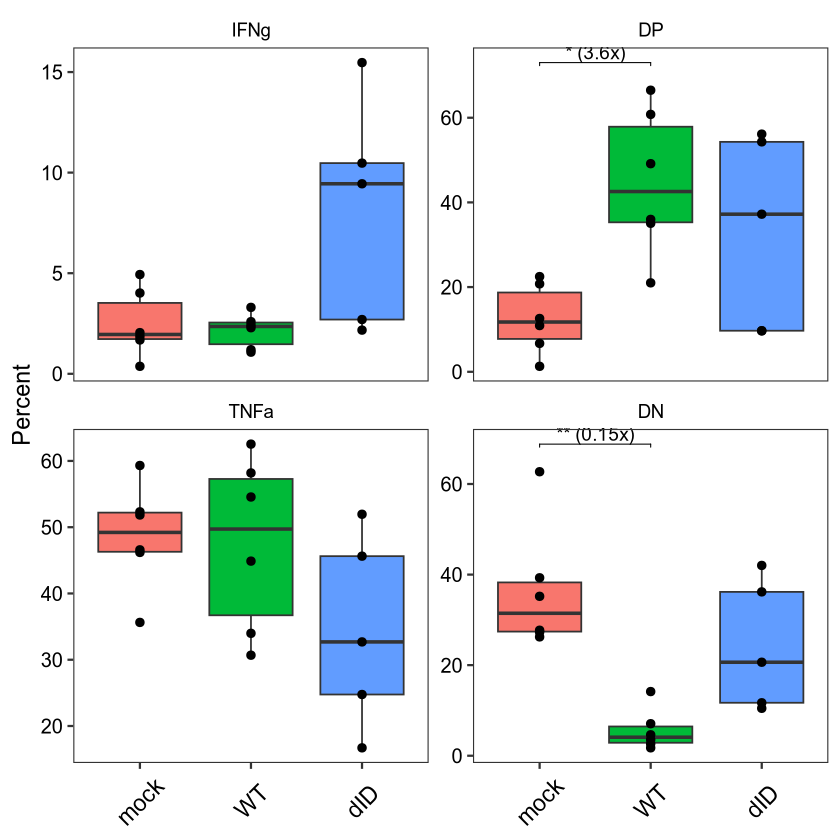

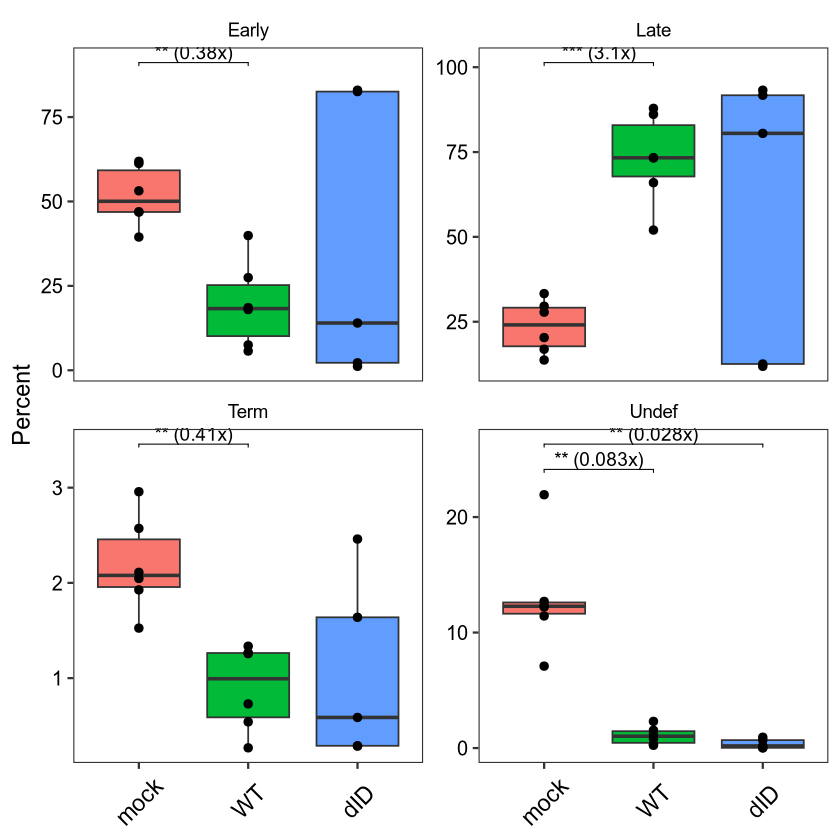

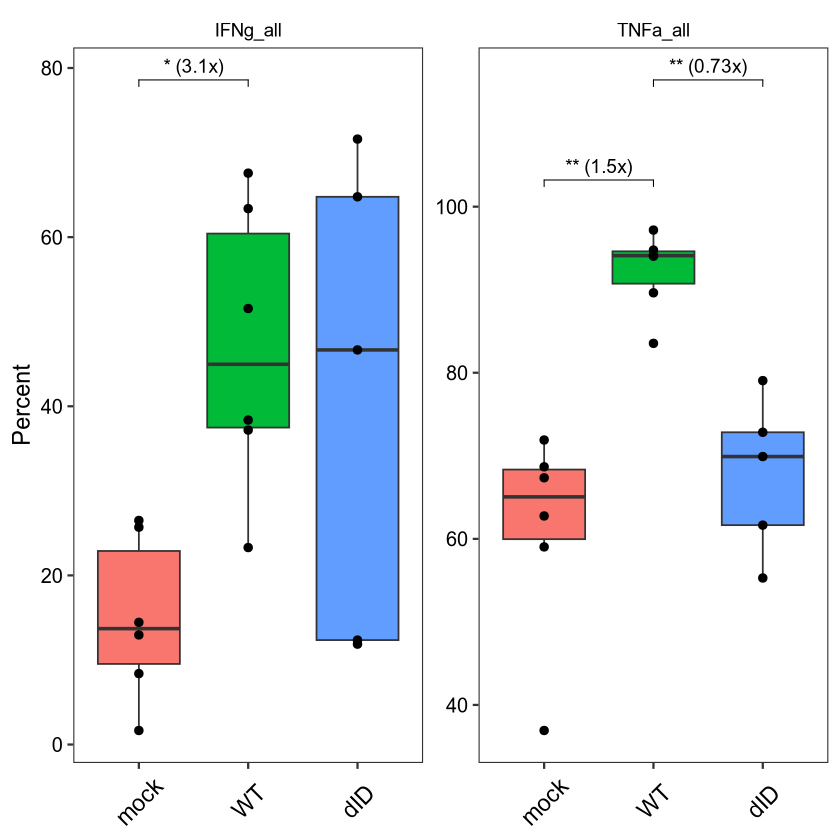

In [10]:
comparisons <- list(
    c("mock", "WT"),
    c("mock", "dID"),
    c("WT", "dID")
)

# Loop on all schemas on the Population2Deriv level
# Plot Percents
for(schema in p.schemas.names) {

    # Select only Population3Deriv with "Schema-" schema with no Population4Deriv
    # Factor Population3Deriv to have levels in order of appearance
    plot.data.df <- total_percent %>%
        filter(
            Stim == "ReStim",
            Population2Deriv %in% p.schemas[[schema]]
            ) %>%
        mutate(
            Population2Deriv = factor(
                Population2Deriv, 
                levels = 
                    p.schemas[[schema]],
                    ),
            Group = factor(Group, levels = d.schemas[["Group"]]),
        )
        

    # Calculate p-values and adjusted p-values for comparisons using plot_padj function
    plot.stat.df <- plot_padj(
        data = plot.data.df,
        comparisons = comparisons,
        y_col = "Percent",
        x_col = "Group",
        facet_col = "Population2Deriv",
        step_fraction = 0.1,
        min_step = 0.5
    )
    # Save plot.stat.df to a CSV file for inspection
    write.csv(plot.stat.df, paste0("stats/allTransferred_xTransferDay_yPercent_", schema, ".csv"))

    # Round plot.stat.df column foldmean to one significant digit
    # Then concatenate to p.adj.signif only if not "ns", into column p.adj.fold
    plot.stat.df <- plot.stat.df %>%
        mutate(foldmeanround = signif(foldmean, digits = 2)) %>%
        mutate(p.adj.fold = ifelse(p.adj.signif == "ns", "ns", paste0(p.adj.signif, " (", foldmeanround, "x)")))

    p <- ggplot(plot.data.df, aes(x = Group, y = Percent, fill = Group)) +
        geom_boxplot(outlier.shape = NA) +
        geom_point(size = 2) +
        facet_wrap(~Population2Deriv, ncol = 2, scales = "free_y") +
        theme +
        stat_pvalue_manual(
            plot.stat.df %>% filter(p.adj < 0.05),
            label = "p.adj.fold",   # adjusted p-value stars
            tip.length = 0.01,
            size = 4,
            inherit.aes = FALSE       # important fix
        )

    print(p)
    
    if(schema == "CXCR6"){
        w <- h <- 15
    } else {
        w <- 10
        h <- 10
    }

    ggsave(
        filename = paste0("plots/allTransferred_xTransferDay_yPercent_", schema, ".pdf"),
        plot = p,
        width = w,
        height = h,
        units = "in"
    )

}



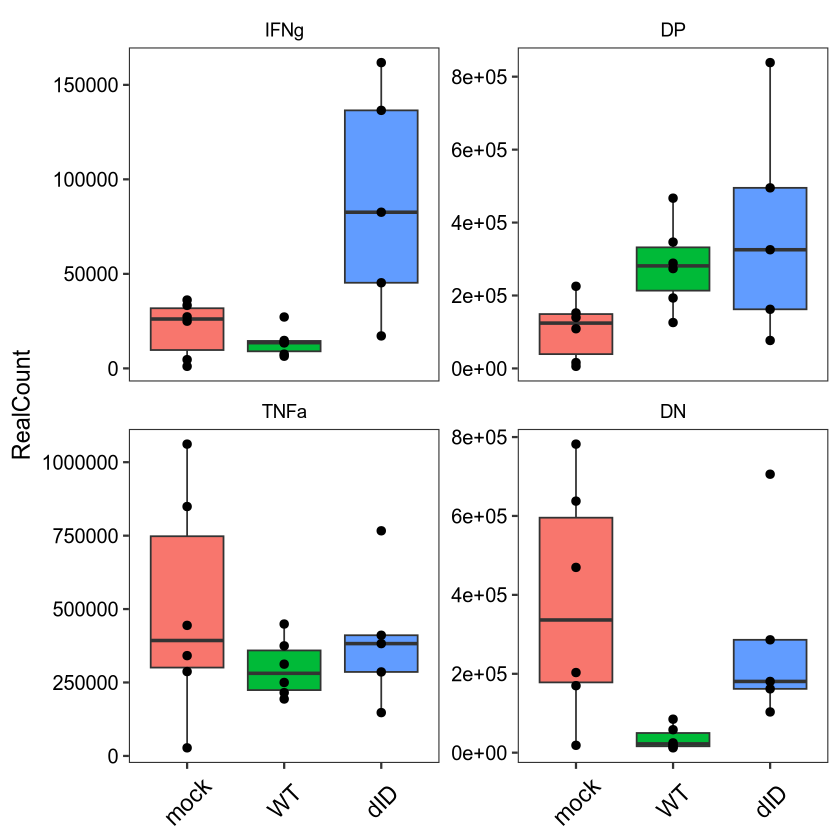

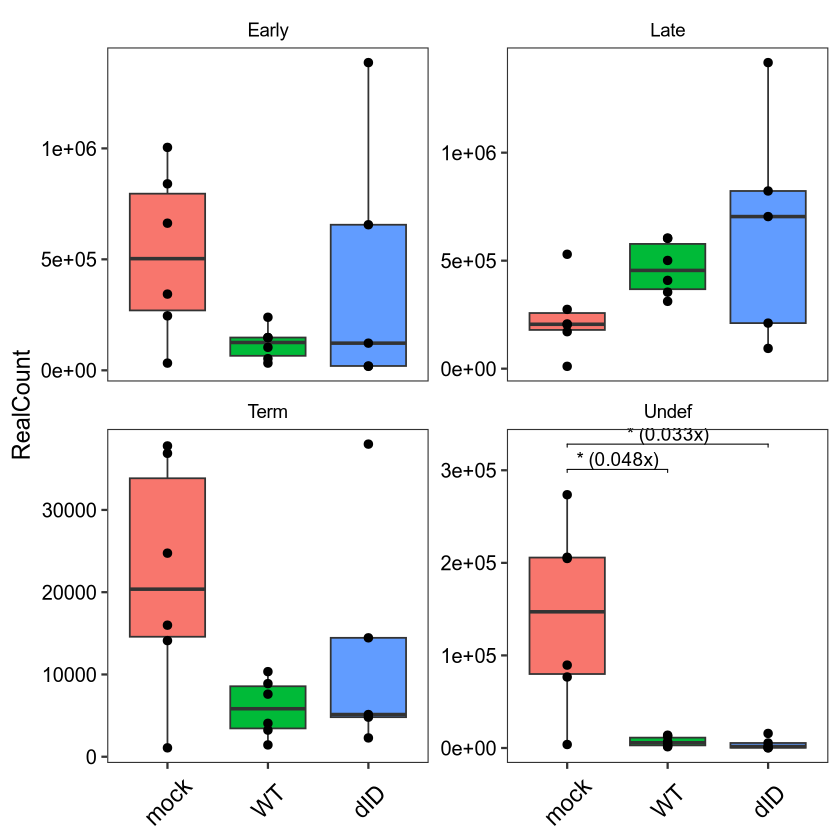

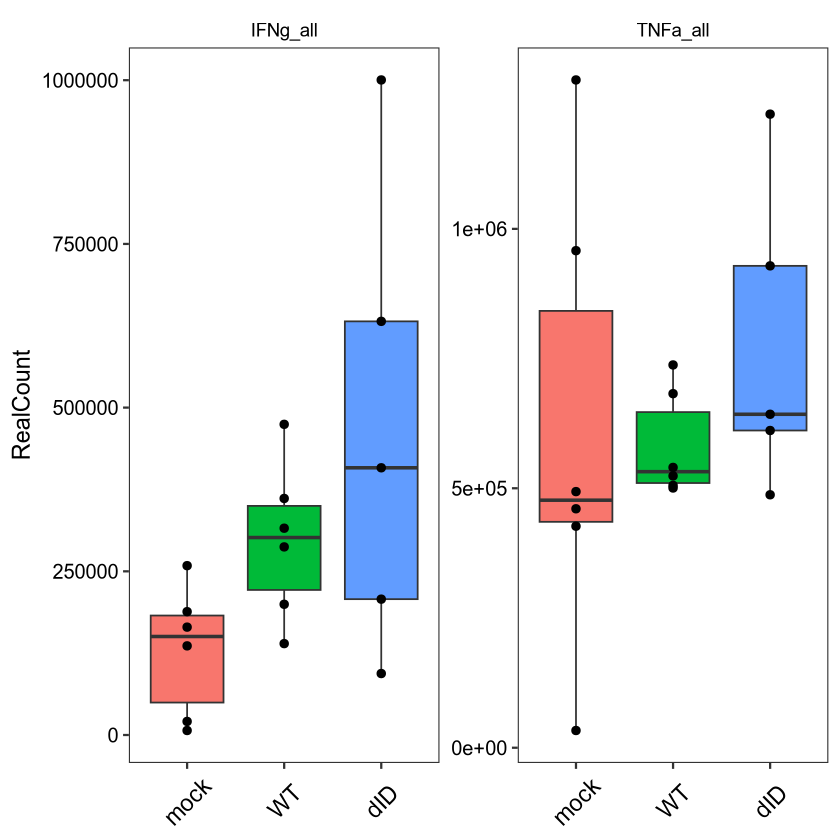

In [11]:
comparisons <- list(
    c("mock", "WT"),
    c("mock", "dID"),
    c("WT", "dID")
)

# Loop on all schemas on the Population2Deriv level
# Plot Percents
for(schema in p.schemas.names) {

    # Select only Population3Deriv with "Schema-" schema with no Population4Deriv
    # Factor Population3Deriv to have levels in order of appearance
    plot.data.df <- total_percent %>%
        filter(
            Stim == "ReStim",
            Population2Deriv %in% p.schemas[[schema]]
            ) %>%
        mutate(
            Population2Deriv = factor(
                Population2Deriv, 
                levels = 
                    p.schemas[[schema]],
                    ),
            Group = factor(Group, levels = d.schemas[["Group"]]),
        )
        

    # Calculate p-values and adjusted p-values for comparisons using plot_padj function
    plot.stat.df <- plot_padj(
        data = plot.data.df,
        comparisons = comparisons,
        y_col = "RealCount",
        x_col = "Group",
        facet_col = "Population2Deriv",
        step_fraction = 0.1,
        min_step = 0.5
    )
    # Save plot.stat.df to a CSV file for inspection
    write.csv(plot.stat.df, paste0("stats/allTransferred_xTransferDay_yRealCount_", schema, ".csv"))

    # Round plot.stat.df column foldmean to one significant digit
    # Then concatenate to p.adj.signif only if not "ns", into column p.adj.fold
    plot.stat.df <- plot.stat.df %>%
        mutate(foldmeanround = signif(foldmean, digits = 2)) %>%
        mutate(p.adj.fold = ifelse(p.adj.signif == "ns", "ns", paste0(p.adj.signif, " (", foldmeanround, "x)")))

    p <- ggplot(plot.data.df, aes(x = Group, y = RealCount, fill = Group)) +
        geom_boxplot(outlier.shape = NA) +
        geom_point(size = 2) +
        facet_wrap(~Population2Deriv, ncol = 2, scales = "free_y") +
        theme +
        stat_pvalue_manual(
            plot.stat.df %>% filter(p.adj < 0.05),
            label = "p.adj.fold",   # adjusted p-value stars
            tip.length = 0.01,
            size = 4,
            inherit.aes = FALSE       # important fix
        )

    print(p)
    
    if(schema == "CXCR6"){
        w <- h <- 15
    } else {
        w <- 10
        h <- 10
    }

    ggsave(
        filename = paste0("plots/allTransferred_xTransferDay_yRealCount_", schema, ".pdf"),
        plot = p,
        width = w,
        height = h,
        units = "in"
    )

}